#### Import Libraries

In [2]:
import numpy as np

import torch
import torch.nn as nn

import librosa
import librosa.display

import seaborn as sns
import matplotlib.pyplot as plt

As we have noticed the class imbalance of our data in EDA module. We have to augment data in order to acheive more impactfull results. Some class for example, Asthma and LRTI must drop because of too many class counts.

And other classes like Healthy and Pneumonia has enought number of sample to augment data.

There are some techniques we can use to augment data for audio. Just like image augmentation (rotate, brightness, shifting, and etc) we have some audio domain augmentation techniques.

In [6]:
# Load waveform
waveform, sr = librosa.load(r"ICBHI_final_database\101_1b1_Al_sc_Meditron.wav", sr=16000)
waveform = waveform[:16000] # We are only using 1st second part waveform to visually it clearly.

#### Noise injection

We can simple introduce noise or most specifically gaussian noise to our waveform, which will create another but similary waveform.

We are using gaussian noise because normal curve or gaussian curve is most predictable

Text(0.5, 36.72222222222221, 'After White Noise Injection')

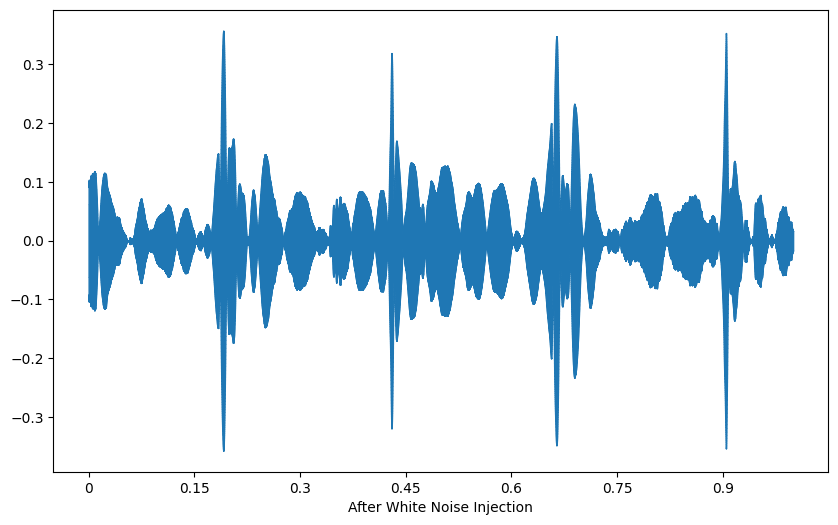

In [12]:
noise_factor = 0.0005  
white_noise = np.random.randn(len(waveform)) * noise_factor
waveform_white_noise = waveform + white_noise

plt.figure(figsize=(10, 6))
librosa.display.waveshow(waveform, sr=sr)
plt.xlabel("After White Noise Injection")

#### Shifting

We can also shift our audio file, with numpy.roll method it is easy.

Text(0.5, 36.72222222222221, 'After Shifting')

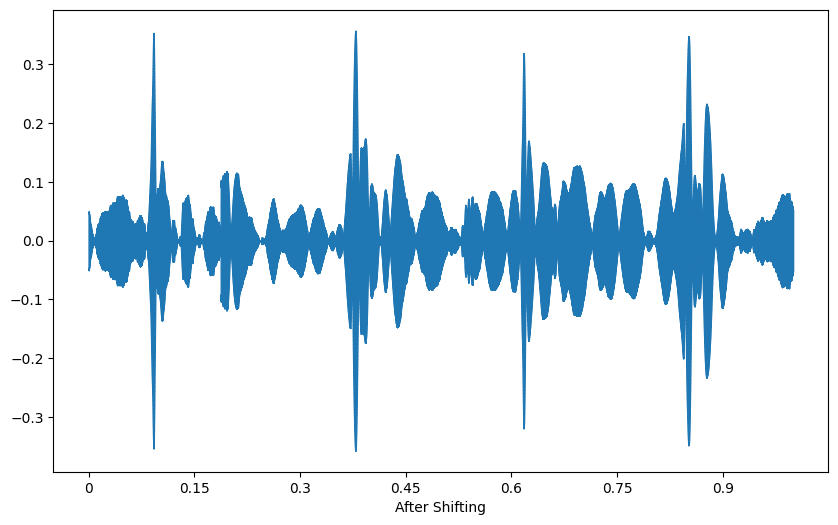

In [13]:
shifted_waveform = np.roll(waveform, 3000)

plt.figure(figsize=(10, 6))
librosa.display.waveshow(shifted_waveform, sr=sr)
plt.xlabel("After Shifting")

#### Streach Audio

Text(0.5, 36.72222222222221, 'After Stretching Injection')

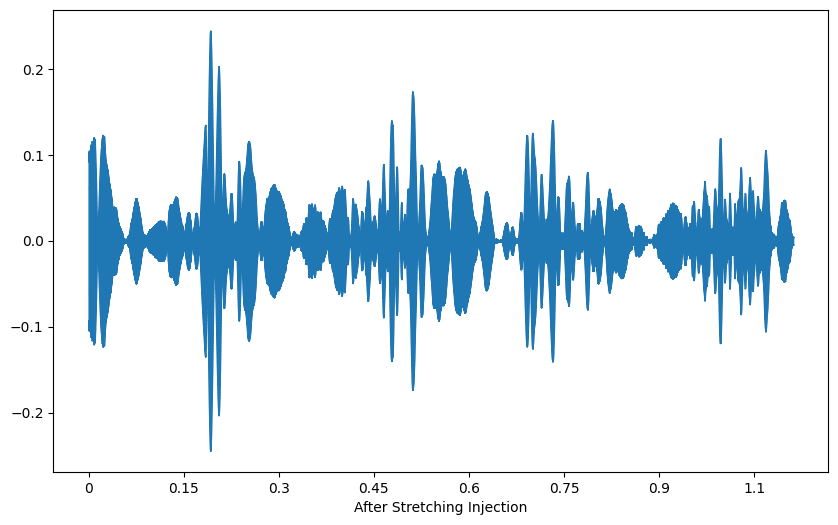

In [15]:
rate = 0.9  
stretched_waveform = librosa.effects.time_stretch(waveform, rate=rate)

plt.figure(figsize=(10, 6))
librosa.display.waveshow(stretched_waveform, sr=sr)
plt.xlabel("After Stretching Injection")

#### Alter frequency or Pitch

Text(0.5, 36.72222222222221, 'Altered Pitch Waveform')

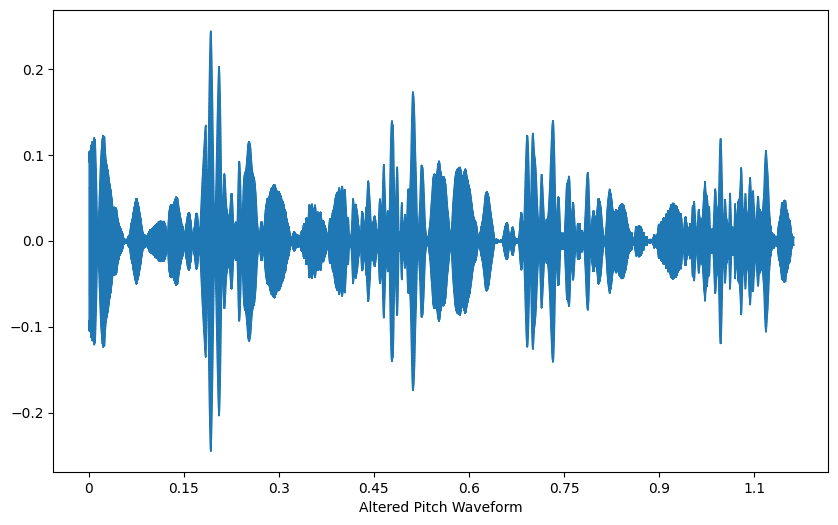

In [16]:
pitch_audio = librosa.effects.pitch_shift(waveform, sr=sr, n_steps=4)

plt.figure(figsize=(10, 6))
librosa.display.waveshow(stretched_waveform, sr=sr)
plt.xlabel("Altered Pitch Waveform")

### Visualize alltogether

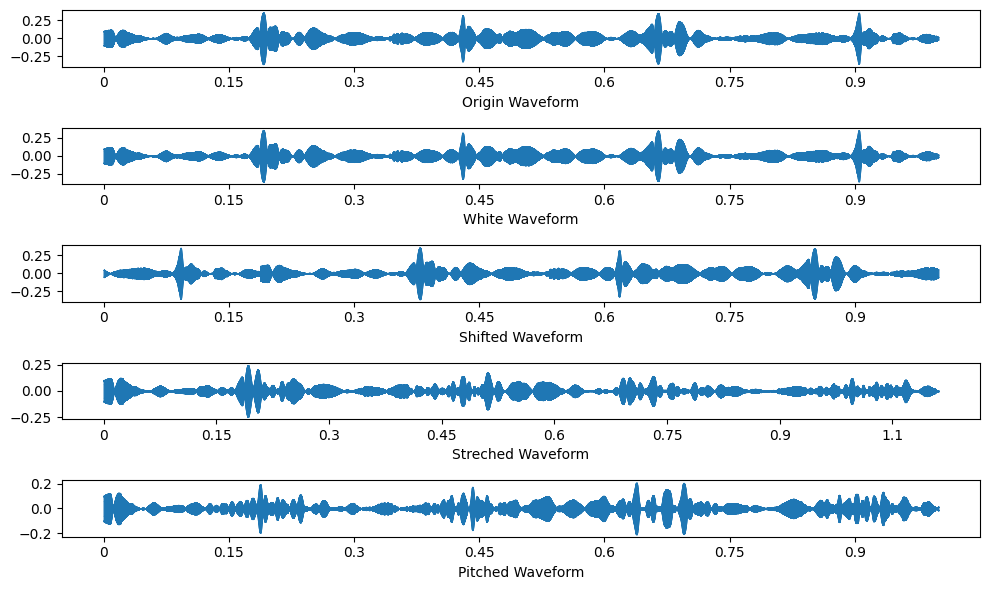

In [17]:
fig, ax = plt.subplots(5, 1, figsize=(10, 6))

librosa.display.waveshow(waveform, sr=sr, ax=ax[0])
ax[0].set_xlabel("Origin Waveform")

librosa.display.waveshow(waveform_white_noise, sr=sr, ax=ax[1])
ax[1].set_xlabel("White Waveform")

librosa.display.waveshow(shifted_waveform, sr=sr, ax=ax[2])
ax[2].set_xlabel("Shifted Waveform")

librosa.display.waveshow(stretched_waveform, sr=sr, ax=ax[3])
ax[3].set_xlabel("Streched Waveform")

librosa.display.waveshow(pitch_audio, sr=sr, ax=ax[4])
ax[4].set_xlabel("Pitched Waveform")

plt.tight_layout()

#### You can we listen the difference between each augmented waveform.

Again, for clear visualization we are only using 1 seconds of waveform, to hear it clearly use full waveform.

In [18]:
from IPython.display import Audio

Audio(waveform, rate=sr)

In [19]:
Audio(waveform_white_noise, rate=sr)

In [20]:
Audio(shifted_waveform, rate=sr)

In [21]:
Audio(stretched_waveform, rate=sr)

In [22]:
Audio(pitch_audio, rate=sr)

#### Have you noiced? All the above audio has same function, but little difference. 